# Confusion-matrix validation — Milan / Hanoi / HCMC raster catalogue

Focused validation of the raster catalogue below against the 2018 ground truth, using **three**
techniques — **A**, a continuous-value agreement (RMSE / MAE / bias / R2 on the raw
predicted %, no threshold and no binning); **B**, a hard confusion matrix at a 50 % cut-off;
and **C**, a fraction-level (10-class) confusion matrix with no threshold. Same ground-truth parsing and metric formulae as the main
validation notebook (`imd_groundtruth_validation.ipynb`); scope and rasters differ.

## Raster catalogue  (20 rasters — 10 for Milan, 5 each for Hanoi and HCMC)

| dataset | code name | source file |
|---|---|---|
| Milan 2018 | `S2_stack`     | `IMD/outputs_S2_stack/IMD_predicted_RF_S2_Milan.tif` |
| Milan 2018 | `S2_percentile`| `IMD/outputs_S2_percentile_p10p25p50p75p90/IMD_predicted_RF_S2_Milan.tif` |
| Milan 2018 | `S2_median`    | `IMD/outputs_S2_median/IMD_predicted_RF_S2_Milan.tif` |
| Milan 2018 | `emb_RF`       | `IMD/outputs_v2/IMD_predicted_RF_spatialCV2_Milan.tif` |
| Milan 2018 | `CLMS`         | `matej_files_codes/reference_IMD/IMD_2018_CLMS_Milan.tif` |
| Milan 2018 | `emb_GHSL`           | `IMD/outputs_GHSL/GHSL_predicted_RF_spatialCV2_Milan.tif` |
| Milan 2018 | `S2_median_GHSL`     | `IMD/outputs_S2_median_GHSL/GHSL_predicted_RF_S2_Milan.tif` |
| Milan 2018 | `S2_stack_GHSL`      | `IMD/outputs_S2_stack_GHSL/GHSL_predicted_RF_S2_Milan.tif` |
| Milan 2018 | `S2_percentile_GHSL` | `IMD/outputs_S2_percentile_p10p25p50p75p90_GHSL/GHSL_predicted_RF_S2_Milan.tif` |
| Milan 2018 | `GHSL`              | `IMD-Mapping/data/GHSL_2018_Milan_UTM32N.tif` (repo) |
| Hanoi 2018 | `emb_localrf`        | `IMD/outputs_transfer_v2/IMD_Hanoi_10m_localrf.tif` |
| Hanoi 2018 | `emb_zeroshot`       | `IMD/outputs_transfer_v2/IMD_Hanoi_10m_zeroshot.tif` |
| Hanoi 2018 | `s2_median_localrf`  | `IMD/outputs_transfer_S2_median/IMD_Hanoi_10m_localrf_S2median.tif` |
| Hanoi 2018 | `s2_median_zeroshot` | `IMD/outputs_transfer_S2_median/IMD_Hanoi_10m_zeroshot_S2median.tif` |
| Hanoi 2018 | `GHSL`               | `matej_files_codes/reference_IMD/IMD_2018_Hanoi.tif` |
| HCMC 2018  | `emb_localrf`        | `IMD/outputs_transfer_v2/IMD_HCMC_10m_localrf.tif` |
| HCMC 2018  | `emb_zeroshot`       | `IMD/outputs_transfer_v2/IMD_HCMC_10m_zeroshot.tif` |
| HCMC 2018  | `s2_median_localrf`  | `IMD/outputs_transfer_S2_median/IMD_HCMC_10m_localrf_S2median.tif` |
| HCMC 2018  | `s2_median_zeroshot` | `IMD/outputs_transfer_S2_median/IMD_HCMC_10m_zeroshot_S2median.tif` |
| HCMC 2018  | `GHSL`               | `matej_files_codes/reference_IMD/IMD_2018_HCMC.tif` |

All source files live under `OneDrive/00LCZ/Matej_impervious/`. The ground-truth CSV is
chosen **by city name** from `Groundtruth_validation/input/`:
`milan_imd_2018_results_cells.csv`, `hanoi_imd_2018_results_cells.csv`,
`hcmc_imd_2018_results_cells.csv` — 450 plots each.

`emb_GHSL`, `S2_median_GHSL`, `S2_stack_GHSL` and `S2_percentile_GHSL` (Milan) are the same
Random-Forest pipelines as `emb_RF` / `S2_*` but trained and tested against GHS-BUILT-S 2018
instead of CLMS; `GHSL` is the raw GHS-BUILT-S reference itself, scored against the photo
ground truth the same way `CLMS` is. `emb_RF` (Milan) is a Random-Forest model trained on
Tessera/embedding features with spatial cross-validation; `emb_localrf` / `emb_zeroshot` (Hanoi, HCMC) are the same family transferred
to the two Vietnamese cities, trained locally or applied zero-shot; `s2_median_*` are the
equivalent models built on median-composite Sentinel-2 features instead of embeddings;
`S2_stack/percentile/median` are three Sentinel-2 feature-aggregation variants of the Milan RF
model; `CLMS` / `GHSL` are the external reference imperviousness products for Europe and for
Vietnam respectively.

## 0 · Setup — paths and raster catalogue

`MATEJ` is the folder holding the raster catalogue; `GT` is the `Groundtruth_validation`
folder holding the ground-truth CSVs. `BIN_THRESHOLD` is the 50 % cut-off for Technique B.

In [1]:
import json, warnings, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import rasterio
from pyproj import Transformer
from sklearn.metrics import confusion_matrix, cohen_kappa_score, f1_score, accuracy_score

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

MATEJ = Path(r"C:\Users\user\OneDrive - Politecnico di Milano\00LCZ\Matej_impervious")
REPO  = Path(r"C:\Users\user\projects\IMD-Mapping")
GT    = Path(r"C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - PhD_Keerthana\test_embeddings\Groundtruth_validation")
RESULTS = GT / "output" / "confusion_matrix_validation"
CROSS   = RESULTS / "cross_city"
CROSS.mkdir(parents=True, exist_ok=True)

BIN_THRESHOLD = 50.0

DATASETS = {
    "Milan_2018": dict(csv=GT / "input" / "milan_imd_2018_results_cells.csv", rasters={
        "S2_stack":      MATEJ / "IMD" / "outputs_S2_stack" / "IMD_predicted_RF_S2_Milan.tif",
        "S2_percentile": MATEJ / "IMD" / "outputs_S2_percentile_p10p25p50p75p90" / "IMD_predicted_RF_S2_Milan.tif",
        "S2_median":     MATEJ / "IMD" / "outputs_S2_median" / "IMD_predicted_RF_S2_Milan.tif",
        "emb_RF":        MATEJ / "IMD" / "outputs_v2" / "IMD_predicted_RF_spatialCV2_Milan.tif",
        "CLMS":          MATEJ / "matej_files_codes" / "reference_IMD" / "IMD_2018_CLMS_Milan.tif",
        # GHSL-labelled runs (trained/tested on GHS-BUILT-S, not CLMS) + the GHS-BUILT-S reference itself
        "emb_GHSL":           MATEJ / "IMD" / "outputs_GHSL" / "GHSL_predicted_RF_spatialCV2_Milan.tif",
        "S2_median_GHSL":     MATEJ / "IMD" / "outputs_S2_median_GHSL" / "GHSL_predicted_RF_S2_Milan.tif",
        "S2_stack_GHSL":      MATEJ / "IMD" / "outputs_S2_stack_GHSL" / "GHSL_predicted_RF_S2_Milan.tif",
        "S2_percentile_GHSL": MATEJ / "IMD" / "outputs_S2_percentile_p10p25p50p75p90_GHSL" / "GHSL_predicted_RF_S2_Milan.tif",
        "GHSL":               REPO / "data" / "GHSL_2018_Milan_UTM32N.tif",
    }),
    "Hanoi_2018": dict(csv=GT / "input" / "hanoi_imd_2018_results_cells.csv", rasters={
        "emb_localrf":        MATEJ / "IMD" / "outputs_transfer_v2" / "IMD_Hanoi_10m_localrf.tif",
        "emb_zeroshot":       MATEJ / "IMD" / "outputs_transfer_v2" / "IMD_Hanoi_10m_zeroshot.tif",
        "s2_median_localrf":  MATEJ / "IMD" / "outputs_transfer_S2_median" / "IMD_Hanoi_10m_localrf_S2median.tif",
        "s2_median_zeroshot": MATEJ / "IMD" / "outputs_transfer_S2_median" / "IMD_Hanoi_10m_zeroshot_S2median.tif",
        "GHSL":               MATEJ / "matej_files_codes" / "reference_IMD" / "IMD_2018_Hanoi.tif",
    }),
    "HCMC_2018": dict(csv=GT / "input" / "hcmc_imd_2018_results_cells.csv", rasters={
        "emb_localrf":        MATEJ / "IMD" / "outputs_transfer_v2" / "IMD_HCMC_10m_localrf.tif",
        "emb_zeroshot":       MATEJ / "IMD" / "outputs_transfer_v2" / "IMD_HCMC_10m_zeroshot.tif",
        "s2_median_localrf":  MATEJ / "IMD" / "outputs_transfer_S2_median" / "IMD_HCMC_10m_localrf_S2median.tif",
        "s2_median_zeroshot": MATEJ / "IMD" / "outputs_transfer_S2_median" / "IMD_HCMC_10m_zeroshot_S2median.tif",
        "GHSL":               MATEJ / "matej_files_codes" / "reference_IMD" / "IMD_2018_HCMC.tif",
    }),
}
DS_ORDER = list(DATASETS)
CITY_DIR = {}
for ds in DS_ORDER:
    CITY_DIR[ds] = RESULTS / ds
    (CITY_DIR[ds] / "comparison").mkdir(parents=True, exist_ok=True)
    for r in DATASETS[ds]["rasters"]:
        (CITY_DIR[ds] / "per_raster" / r).mkdir(parents=True, exist_ok=True)

n_pairs = sum(len(d["rasters"]) for d in DATASETS.values())
print(f"{len(DATASETS)} datasets, {n_pairs} (dataset, raster) pairs")
for ds, d in DATASETS.items():
    print(f"  {ds:11s} csv={'ok' if d['csv'].exists() else 'MISSING'}")
    for r, p in d["rasters"].items():
        print(f"      {r:20s} {'ok' if p.exists() else 'MISSING'}  {p.name}")
print("results ->", RESULTS)

3 datasets, 20 (dataset, raster) pairs
  Milan_2018  csv=ok
      S2_stack             ok  IMD_predicted_RF_S2_Milan.tif
      S2_percentile        ok  IMD_predicted_RF_S2_Milan.tif
      S2_median            ok  IMD_predicted_RF_S2_Milan.tif
      emb_RF               ok  IMD_predicted_RF_spatialCV2_Milan.tif
      CLMS                 ok  IMD_2018_CLMS_Milan.tif
      emb_GHSL             ok  GHSL_predicted_RF_spatialCV2_Milan.tif
      S2_median_GHSL       ok  GHSL_predicted_RF_S2_Milan.tif
      S2_stack_GHSL        ok  GHSL_predicted_RF_S2_Milan.tif
      S2_percentile_GHSL   ok  GHSL_predicted_RF_S2_Milan.tif
      GHSL                 ok  GHSL_2018_Milan_UTM32N.tif
  Hanoi_2018  csv=ok
      emb_localrf          ok  IMD_Hanoi_10m_localrf.tif
      emb_zeroshot         ok  IMD_Hanoi_10m_zeroshot.tif
      s2_median_localrf    ok  IMD_Hanoi_10m_localrf_S2median.tif
      s2_median_zeroshot   ok  IMD_Hanoi_10m_zeroshot_S2median.tif
      GHSL                 ok  IMD_2018_Hanoi.tif


## 1 · Shared functions

Identical surface classifier and metric engines to the main validation notebook, restricted to
the three techniques.

* `classify_surface` — sub-cell label → impervious(1) / pervious(0), by prefix then keyword.
* `continuous_metrics` — **Technique A**: raw predicted % vs photo-interpreted %, no
  threshold and no binning — RMSE, MAE, bias (observed minus predicted), R2, Pearson r.
* `binary_metrics` — **Technique B**: hard 2×2 confusion at `BIN_THRESHOLD`, plot-count units.
* `level_confusion` — **Technique C**: 10×10 confusion over the discrete levels 0/9…9/9,
  no threshold.

In [2]:
_KW_IMP = ("building", "roof", "road", "asphalt", "pavement", "concrete", "sidewalk", "parking",
           "industrial", "airport", "runway", "railroad", "rail track", "ballast", "swimming pool",
           "rock", "material")
_KW_PER = ("grass", "lawn", "park", "vegetation", "tree", "canopy", "forest", "bare soil", "silt",
           "plowed", "agricultur", "unpaved", "dirt road", "water", "wetland", "crop", "shrub",
           "soil", "sand", "permeable pavement")

def classify_surface(label):
    if label is None or (isinstance(label, float) and np.isnan(label)):
        return np.nan
    s = str(label).strip().lower()
    if not s or s == "nan":
        return np.nan
    while s.startswith("perviouspervious"):
        s = s[len("pervious"):]
    if s.startswith("impervious"):
        return 1
    if s.startswith("pervious"):
        return 0
    if "permeable pavement" in s:
        return 0
    if any(k in s for k in _KW_PER):
        return 0
    if any(k in s for k in _KW_IMP):
        return 1
    return np.nan

def binary_metrics(gt_bin, pred_bin):
    cm = confusion_matrix(gt_bin, pred_bin, labels=[0, 1])
    (tn, fp), (fn, tp) = cm
    return cm, dict(
        n=int(cm.sum()), OA=accuracy_score(gt_bin, pred_bin), kappa=cohen_kappa_score(gt_bin, pred_bin),
        PA_pervious=tn/(tn+fp) if (tn+fp) else np.nan, PA_impervious=tp/(tp+fn) if (tp+fn) else np.nan,
        UA_pervious=tn/(tn+fn) if (tn+fn) else np.nan, UA_impervious=tp/(tp+fp) if (tp+fp) else np.nan,
        F1_impervious=f1_score(gt_bin, pred_bin, pos_label=1, zero_division=0))

def level_confusion(df, rcol, k=9):
    g = df.gt_imperv_pct.values / 100.0
    p = np.clip(df[rcol].values / 100.0, 0, 1)
    m = np.isfinite(g) & np.isfinite(p)
    gl = np.clip(np.round(g[m] * k), 0, k).astype(int)
    pl = np.clip(np.round(p[m] * k), 0, k).astype(int)
    lab = [f"{i}/9" for i in range(k + 1)]
    C = pd.DataFrame(0, index=pd.Index(lab, name="reference"),
                     columns=pd.Index(lab, name="predicted"), dtype=float)
    for a, b in zip(gl, pl):
        C.iat[a, b] += 1
    Cv = C.values; N = Cv.sum(); idx = np.arange(k + 1)
    d = np.abs(idx[:, None] - idx[None, :])
    exact = np.trace(Cv) / N; within1 = Cv[d <= 1].sum() / N
    mae_lv = (Cv * d).sum() / N; rmse_lv = np.sqrt((Cv * d**2).sum() / N)
    W = (d / k) ** 2
    row, col = Cv.sum(1), Cv.sum(0)
    E = np.outer(row, col) / N
    qwk = 1 - (W * Cv).sum() / (W * E).sum() if (W * E).sum() else np.nan
    per = pd.DataFrame({
        "n_ref": row, "n_pred": col,
        "producers_acc": np.divide(np.diag(Cv), row, out=np.full(k+1, np.nan), where=row > 0),
        "users_acc":     np.divide(np.diag(Cv), col, out=np.full(k+1, np.nan), where=col > 0),
    }, index=lab)
    stats = dict(n=int(N), exact_match_OA=exact, within_1_level_OA=within1,
                 MAE_levels=mae_lv, MAE_pp=mae_lv * 100/k, RMSE_pp=rmse_lv * 100/k,
                 quad_weighted_kappa=qwk)
    return C, per, stats

def continuous_metrics(df, rcol):
    """Continuous agreement between the raw predicted % and the photo-interpreted
    impervious % -- no threshold, no level binning. bias is observed minus
    predicted, so a positive bias means the map under-predicts."""
    g = df.gt_imperv_pct.values.astype(float)
    p = np.clip(df[rcol].values.astype(float), 0, 100)
    m = np.isfinite(g) & np.isfinite(p)
    g, p = g[m], p[m]
    err = p - g
    ss_res = np.sum(err ** 2)
    ss_tot = np.sum((g - g.mean()) ** 2)
    return dict(
        n=int(m.sum()),
        RMSE_pp=float(np.sqrt(np.mean(err ** 2))),
        MAE_pp=float(np.mean(np.abs(err))),
        bias_pp=float(np.mean(g - p)),
        R2=float(1 - ss_res / ss_tot) if ss_tot else np.nan,
        pearson_r=float(np.corrcoef(g, p)[0, 1]) if len(g) > 1 else np.nan,
    )

print("functions ready")

functions ready


## 2 · Load ground truth and extract predictions

Parses each city’s 450-plot CSV into `gt_imperv_pct` / `gt_bin` exactly as in the main
notebook, then samples each of its rasters at the reprojected plot location (point sample,
nodata/out-of-range masked). No plot is dropped for any of the 20 pairs.

In [3]:
def load_dataset(ds):
    cfg = DATASETS[ds]
    raw = pd.read_csv(cfg["csv"])
    frac, nbad = [], []
    for js in raw["cells_json"]:
        flags = [classify_surface(it.get("label")) for it in json.loads(js)]
        flags = np.array(flags, float); good = flags[~np.isnan(flags)]
        frac.append(100.0 * good.mean() if good.size else np.nan)
        nbad.append(int(np.isnan(flags).sum()))
    df = pd.DataFrame({
        "PLOTID": raw["PLOTID"], "LON": raw["LON"].astype(float), "LAT": raw["LAT"].astype(float),
        "gt_density_class": raw["ref_label"],
        "gt_dom_class": raw["class_label"].astype(str)
                            .str.replace("^PerviousPervious", "Pervious", regex=True)
                            .str.replace("Havily", "Heavily").str.strip(),
        "gt_dom_pct": raw["cell_dominant_pct"].astype(float),
        "n_unresolved_subcells": nbad,
        "gt_imperv_pct": np.round(frac, 2),
    })
    df["gt_bin"] = (df.gt_imperv_pct >= 50).astype(int)

    tr_cache = {}
    for rname, rpath in cfg["rasters"].items():
        with rasterio.open(rpath) as src:
            crs = str(src.crs)
            if crs not in tr_cache:
                t = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
                tr_cache[crs] = np.column_stack(t.transform(df.LON.values, df.LAT.values))
            xy = tr_cache[crs]
            b = src.bounds
            inside = ((xy[:, 0] > b.left) & (xy[:, 0] < b.right) &
                      (xy[:, 1] > b.bottom) & (xy[:, 1] < b.top)).sum()
            vals = np.array([v[0] for v in src.sample(xy)], float)
            vals[~np.isfinite(vals)] = np.nan
            vals[(vals < 0) | (vals > 100)] = np.nan
            df[f"pred_{rname}"] = vals
        print(f"  {ds:11s} {rname:20s} {crs}  inside {inside}/{len(df)}  nan {int(np.isnan(vals).sum())}")
    return df

DATA = {ds: load_dataset(ds) for ds in DS_ORDER}
for ds in DS_ORDER:
    DATA[ds].to_csv(CITY_DIR[ds] / "points_extracted.csv", index=False)

summ = pd.DataFrame([{
    "dataset": ds, "n_plots": len(DATA[ds]), "gt_imperv_%_mean": DATA[ds].gt_imperv_pct.mean(),
    "binary_impervious": int(DATA[ds].gt_bin.sum()), "rasters": ", ".join(DATASETS[ds]["rasters"]),
} for ds in DS_ORDER]).set_index("dataset")
summ.to_csv(CROSS / "dataset_summary.csv")
display(summ)

def all_pairs():
    for ds in DS_ORDER:
        for r in DATASETS[ds]["rasters"]:
            yield ds, r

  Milan_2018  S2_stack             EPSG:32632  inside 450/450  nan 0


  Milan_2018  S2_percentile        EPSG:32632  inside 450/450  nan 0


  Milan_2018  S2_median            EPSG:32632  inside 450/450  nan 0


  Milan_2018  emb_RF               EPSG:32632  inside 450/450  nan 0
  Milan_2018  CLMS                 EPSG:32632  inside 450/450  nan 0


  Milan_2018  emb_GHSL             EPSG:32632  inside 450/450  nan 0


...

  Hanoi_2018  GHSL                 EPSG:32648  inside 450/450  nan 0


  HCMC_2018   emb_localrf          EPSG:32648  inside 450/450  nan 0
  HCMC_2018   emb_zeroshot         EPSG:32648  inside 450/450  nan 0


  HCMC_2018   s2_median_localrf    EPSG:32648  inside 450/450  nan 0


  HCMC_2018   s2_median_zeroshot   EPSG:32648  inside 450/450  nan 0
  HCMC_2018   GHSL                 EPSG:32648  inside 450/450  nan 0


,n_plots,gt_imperv_%_mean,binary_impervious,rasters
dataset,,,,
Milan_2018,450,38.741,181,"S2_stack, S2_percentile, S2_median, emb_RF, CL..."
Hanoi_2018,450,46.049,211,"emb_localrf, emb_zeroshot, s2_median_localrf, ..."
HCMC_2018,450,51.062,234,"emb_localrf, emb_zeroshot, s2_median_localrf, ..."


## 3 · Technique A — continuous-value agreement (raw %, no threshold)

The raw raster value at each plot against the photo-interpreted impervious percentage,
with no 50 % cut-off and no snapping to levels. `RMSE_pp` / `MAE_pp` are in percentage
points; `bias_pp` is **observed minus predicted**, so a positive bias means the map
under-predicts; `R2` is the coefficient of determination against the 1:1 line and
`pearson_r` the linear correlation. Written per city to
`comparison/technique_A_continuous_metrics.csv`.

In [4]:
CONT_rows = []
for ds, r in all_pairs():
    CONT_rows.append(dict(dataset=ds, raster=r, **continuous_metrics(DATA[ds], f"pred_{r}")))
TA = pd.DataFrame(CONT_rows).set_index(["dataset", "raster"])
TA.to_csv(CROSS / "technique_A_continuous_metrics.csv")
for ds in DS_ORDER:
    TA.loc[ds].to_csv(CITY_DIR[ds] / "comparison" / "technique_A_continuous_metrics.csv")
print("continuous agreement -- raw predicted % vs photo-interpreted impervious %, no threshold")
print("bias_pp = observed - predicted  (positive => the map under-predicts)")
TA.round(3)

continuous agreement -- raw predicted % vs photo-interpreted impervious %, no threshold
bias_pp = observed - predicted  (positive => the map under-predicts)


n  RMSE_pp  MAE_pp  bias_pp    R2  pearson_r
dataset    raster                                                            
Milan_2018 S2_stack            450   24.563  16.526   -3.319 0.654      0.813
           S2_percentile       450   24.729  16.461   -3.317 0.649      0.810
           S2_median           450   25.911  18.339   -4.151 0.615      0.791
           emb_RF              450   25.560  18.275   -1.597 0.626      0.792
           CLMS                450   26.225  14.831    2.244 0.606      0.788
           emb_GHSL            450   28.919  21.000   10.021 0.521      0.778
           S2_median_GHSL      450   29.254  20.953    9.260 0.509      0.756
           S2_stack_GHSL       450   28.376  20.450    9.192 0.538      0.778
           S2_percentile_GHSL  450   28.229  19.916    9.456 0.543      0.783
           GHSL                450   36.811  24.208   18.968 0.223      0.657
Hanoi_2018 emb_localrf         450   26.502  19.589    6.592 0.649      0.832
           emb_zeroshot        450   34.352  29.537  -15.716 0.410      0.810
           s2_median_localrf   450   27.282  21.320    8.181 0.628      0.841
           s2_median_zeroshot  450   33.792  24.470  -15.876 0.429      0.753
           GHSL                450   40.345  27.053   19.681 0.187      0.618
HCMC_2018  emb_localrf         450   27.243  20.295   11.088 0.630      0.850
           emb_zeroshot        450   38.494  32.404  -19.641 0.262      0.816
           s2_median_localrf   450   29.616  23.030   12.233 0.563      0.822
           s2_median_zeroshot  450   25.951  16.779   -6.827 0.665      0.830
           GHSL                450   37.355  25.730   19.800 0.305      0.707

### 3.1 · Predicted-vs-observed scatter, one row of panels per city

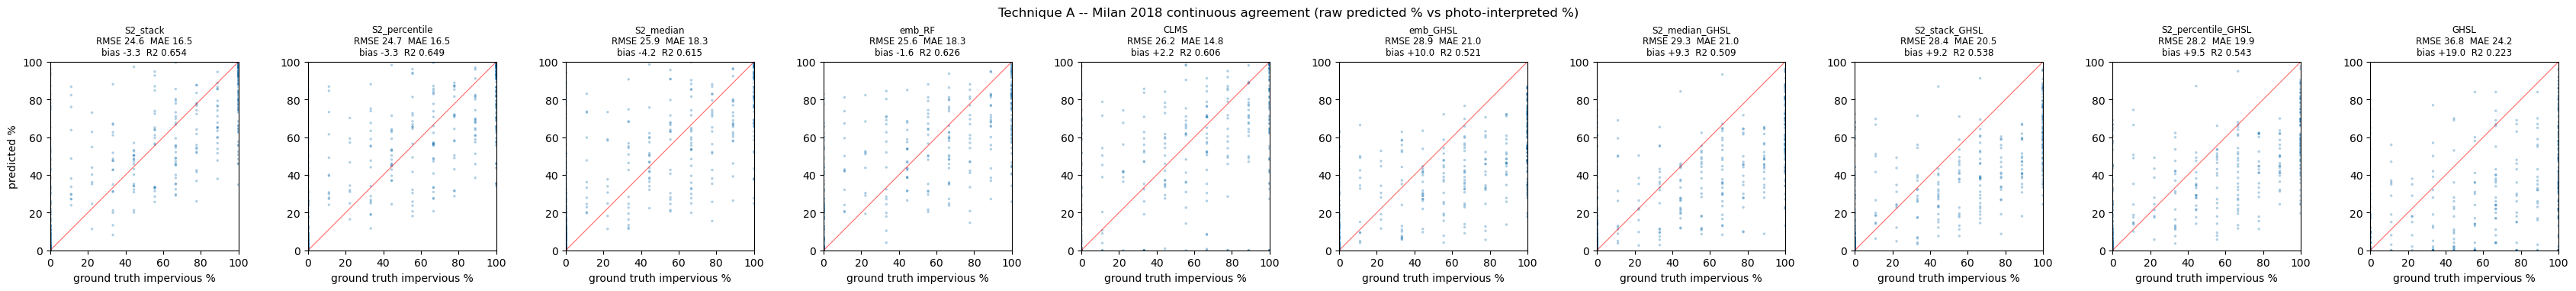

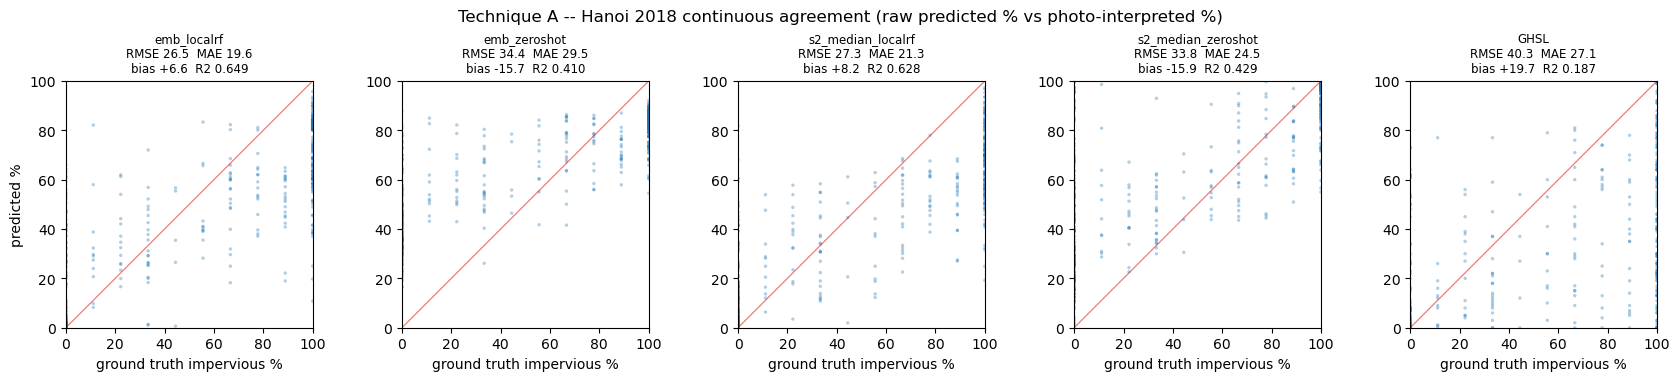

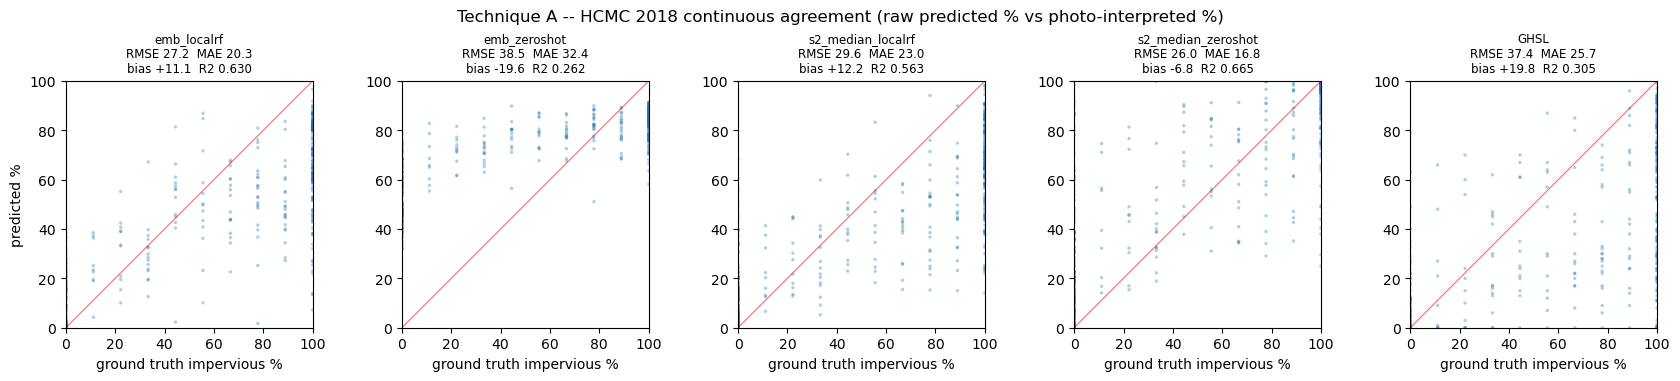

In [5]:
def continuous_grid(ds, savepath):
    rs = list(DATASETS[ds]["rasters"])
    fig, axes = plt.subplots(1, len(rs), figsize=(3.4*len(rs), 3.7), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for i, (ax, r) in enumerate(zip(axes, rs)):
        d = DATA[ds]
        g = d.gt_imperv_pct.values.astype(float)
        p = np.clip(d[f"pred_{r}"].values.astype(float), 0, 100)
        m = np.isfinite(g) & np.isfinite(p)
        st = TA.loc[(ds, r)]
        ax.scatter(g[m], p[m], s=6, alpha=.35, edgecolors="none")
        ax.plot([0, 100], [0, 100], "r-", lw=.8, alpha=.6)
        ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.set_aspect("equal")
        ax.set_xlabel("ground truth impervious %")
        if i == 0:
            ax.set_ylabel("predicted %")
        ax.set_title(f"{r}\nRMSE {st.RMSE_pp:.1f}  MAE {st.MAE_pp:.1f}\n"
                     f"bias {st.bias_pp:+.1f}  R2 {st.R2:.3f}", fontsize=8.5)
    fig.suptitle(f"Technique A -- {ds.replace('_',' ')} continuous agreement "
                 "(raw predicted % vs photo-interpreted %)", fontsize=12)
    fig.savefig(savepath, dpi=140, bbox_inches="tight"); plt.show()

for ds in DS_ORDER:
    continuous_grid(ds, CITY_DIR[ds] / "comparison" / "technique_A_continuous_grid.png")

## 4 · Technique B — hard confusion matrix at a 50 % cut-off

Each plot is labelled impervious if the predicted value is ≥ 50 %, cross-tabulated against
the binary ground truth (majority of the 9 sub-cells). Units are plot counts.
`OA` = overall accuracy; `kappa` = Cohen’s kappa; `PA_*` = producer’s accuracy (recall);
`UA_*` = user’s accuracy (precision); `F1_imp` = harmonic mean of PA/UA for impervious.

In [6]:
rows, cms = [], {}
for ds, r in all_pairs():
    pb = (DATA[ds][f"pred_{r}"] >= BIN_THRESHOLD).astype(int)
    cm, mm = binary_metrics(DATA[ds].gt_bin, pb)
    cms[(ds, r)] = cm
    rows.append(dict(dataset=ds, raster=r, **mm))
TB = pd.DataFrame(rows).set_index(["dataset", "raster"])
TB.to_csv(CROSS / "technique_B_hard_confusion_metrics.csv")
for ds in DS_ORDER:
    TB.loc[ds].to_csv(CITY_DIR[ds] / "comparison" / "technique_B_hard_confusion_metrics.csv")
    for r in DATASETS[ds]["rasters"]:
        pd.DataFrame(cms[(ds, r)], index=["gt_pervious", "gt_impervious"],
                     columns=["pred_pervious", "pred_impervious"]).to_csv(
            CITY_DIR[ds] / "per_raster" / r / "confusion_matrix_50pct.csv")
print(f"threshold = {BIN_THRESHOLD:g} %")
TB.round(3)

threshold = 50 %


n    OA  kappa  PA_pervious  PA_impervious  UA_pervious  UA_impervious  F1_impervious
dataset    raster                                                                                                     
Milan_2018 S2_stack            450 0.851  0.692        0.862          0.834        0.885          0.803          0.818
           S2_percentile       450 0.838  0.666        0.844          0.829        0.880          0.781          0.804
           S2_median           450 0.840  0.670        0.851          0.823        0.877          0.788          0.805
           emb_RF              450 0.820  0.627        0.840          0.790        0.856          0.769          0.779
           CLMS                450 0.824  0.635        0.855          0.779        0.852          0.783          0.781
           emb_GHSL            450 0.762  0.471        0.937          0.503        0.737          0.843          0.630
           S2_median_GHSL      450 0.767  0.484        0.929          0.525        0.744          0.833          0.644
           S2_stack_GHSL       450 0.767  0.483        0.933          0.519        0.743          0.839          0.642
           S2_percentile_GHSL  450 0.784  0.526        0.933          0.564        0.761          0.850          0.678
           GHSL                450 0.702  0.312        0.955          0.326        0.678          0.831          0.468
Hanoi_2018 emb_localrf         450 0.864  0.726        0.912          0.810        0.845          0.891          0.849
           emb_zeroshot        450 0.796  0.599        0.623          0.991        0.987          0.699          0.820
           s2_median_localrf   450 0.864  0.725        0.937          0.782        0.830          0.917          0.844
           s2_median_zeroshot  450 0.804  0.615        0.674          0.953        0.942          0.720          0.820
           GHSL                450 0.700  0.381        0.925          0.445        0.654          0.839          0.582
HCMC_2018  emb_localrf         450 0.840  0.682        0.944          0.744        0.773          0.935          0.829
           emb_zeroshot        450 0.691  0.366        0.356          1.000        1.000          0.627          0.771
           s2_median_localrf   450 0.813  0.630        0.958          0.679        0.734          0.946          0.791
           s2_median_zeroshot  450 0.856  0.710        0.801          0.906        0.887          0.831          0.867
           GHSL                450 0.729  0.466        0.944          0.530        0.650          0.912          0.670

### 4.1 · Confusion-matrix heatmaps, one row of panels per city

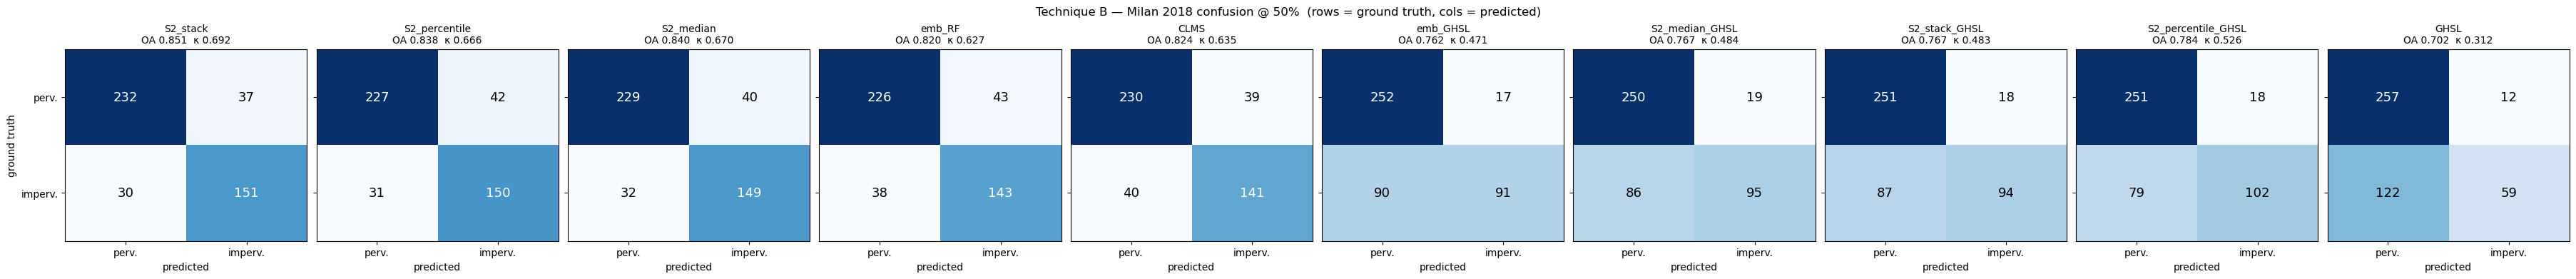

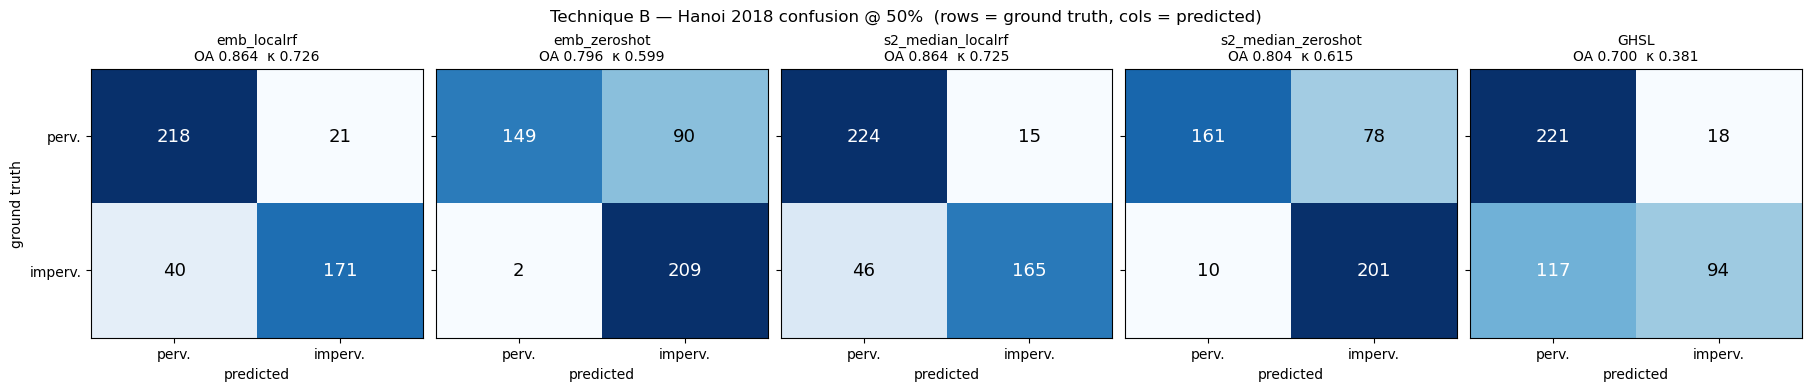

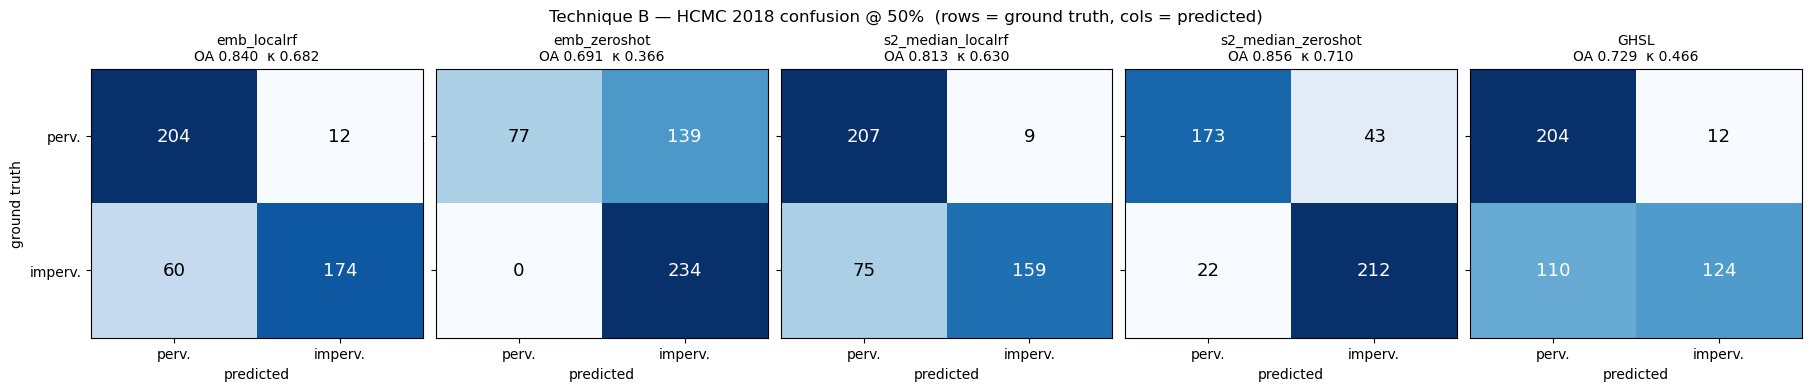

In [7]:
def confusion_grid(ds, savepath):
    rs = list(DATASETS[ds]["rasters"])
    fig, axes = plt.subplots(1, len(rs), figsize=(3.6*len(rs), 3.8), constrained_layout=True)
    axes = np.atleast_1d(axes)
    lab = ["perv.", "imperv."]
    for i, (ax, r) in enumerate(zip(axes, rs)):
        cm = cms[(ds, r)]
        mm = TB.loc[(ds, r)]
        ax.imshow(cm, cmap="Blues", aspect="auto")
        for a in range(2):
            for c in range(2):
                ax.text(c, a, cm[a, c], ha="center", va="center", fontsize=13,
                        color="white" if cm[a, c] > cm.max()/2 else "black")
        ax.set_xticks([0, 1], lab); ax.set_yticks([0, 1], lab if i == 0 else ["", ""])
        ax.set_xlabel("predicted")
        if i == 0:
            ax.set_ylabel("ground truth")
        ax.set_title(f"{r}\nOA {mm.OA:.3f}  \u03ba {mm.kappa:.3f}", fontsize=10)
    fig.suptitle(f"Technique B \u2014 {ds.replace('_',' ')} confusion @ {BIN_THRESHOLD:g}%  "
                 "(rows = ground truth, cols = predicted)", fontsize=12)
    fig.savefig(savepath, dpi=140, bbox_inches="tight"); plt.show()

for ds in DS_ORDER:
    confusion_grid(ds, CITY_DIR[ds] / "comparison" / "technique_B_confusion_grid.png")

## 5 · Technique C — fraction-level confusion matrix (10 classes, no threshold)

No pervious/impervious split. The reference level is the exact impervious sub-cell count
(0/9 = 0.0 % … 9/9 = 100.0 %); the predicted level is the raster value snapped to the nearest
of the same ten steps. Agreement is summarised by exact-match accuracy, within-1-level accuracy
(≈ 11 pp tolerance), quadratic-weighted kappa (ordinal, chance-corrected), and MAE / RMSE in
percentage points. Full 10×10 matrices and per-level producer’s/user’s accuracy are
written per raster.

In [8]:
LV_rows = []
level_mats = {}
for ds, r in all_pairs():
    C, per, st = level_confusion(DATA[ds], f"pred_{r}")
    level_mats[(ds, r)] = (C, per)
    LV_rows.append(dict(dataset=ds, raster=r, **st))
    C.to_csv(CITY_DIR[ds] / "per_raster" / r / "level_confusion_matrix.csv")
    per.round(4).to_csv(CITY_DIR[ds] / "per_raster" / r / "level_confusion_perclass.csv")
TC = pd.DataFrame(LV_rows).set_index(["dataset", "raster"])
TC.to_csv(CROSS / "technique_C_level_confusion_metrics.csv")
for ds in DS_ORDER:
    TC.loc[ds].to_csv(CITY_DIR[ds] / "comparison" / "technique_C_level_confusion_metrics.csv")
print("fraction-level (10-class) agreement \u2014 no pervious/impervious threshold")
TC.round(3)

fraction-level (10-class) agreement — no pervious/impervious threshold


n  exact_match_OA  within_1_level_OA  MAE_levels  MAE_pp  RMSE_pp  quad_weighted_kappa
dataset    raster                                                                                                      
Milan_2018 S2_stack            450           0.349              0.633       1.453  16.148   24.701                0.793
           S2_percentile       450           0.367              0.627       1.478  16.420   25.223                0.788
           S2_median           450           0.240              0.600       1.653  18.370   26.231                0.760
           emb_RF              450           0.311              0.533       1.651  18.346   25.836                0.760
           CLMS                450           0.527              0.689       1.338  14.864   26.460                0.779
           emb_GHSL            450           0.327              0.502       1.869  20.765   29.045                0.665
           S2_median_GHSL      450           0.351              0.533       1.840  20.444   29.322                0.668
           S2_stack_GHSL       450           0.364              0.538       1.791  19.901   28.478                0.687
           S2_percentile_GHSL  450           0.387              0.553       1.733  19.259   28.129                0.696
           GHSL                450           0.433              0.527       2.182  24.247   36.993                0.504
Hanoi_2018 emb_localrf         450           0.309              0.509       1.747  19.407   26.831                0.760
           emb_zeroshot        450           0.042              0.289       2.638  29.309   34.446                0.561
           s2_median_localrf   450           0.240              0.473       1.884  20.938   27.357                0.741
           s2_median_zeroshot  450           0.249              0.456       2.176  24.173   34.062                0.631
           GHSL                450           0.389              0.504       2.418  26.864   40.355                0.501
HCMC_2018  emb_localrf         450           0.276              0.473       1.827  20.296   27.676                0.750
           emb_zeroshot        450           0.049              0.358       2.882  32.025   38.444                0.448
           s2_median_localrf   450           0.202              0.462       2.049  22.765   29.833                0.703
           s2_median_zeroshot  450           0.389              0.642       1.469  16.321   25.942                0.803
           GHSL                450           0.320              0.493       2.309  25.654   37.277                0.590

### 5.1 · Level-confusion heatmaps, one row of panels per city

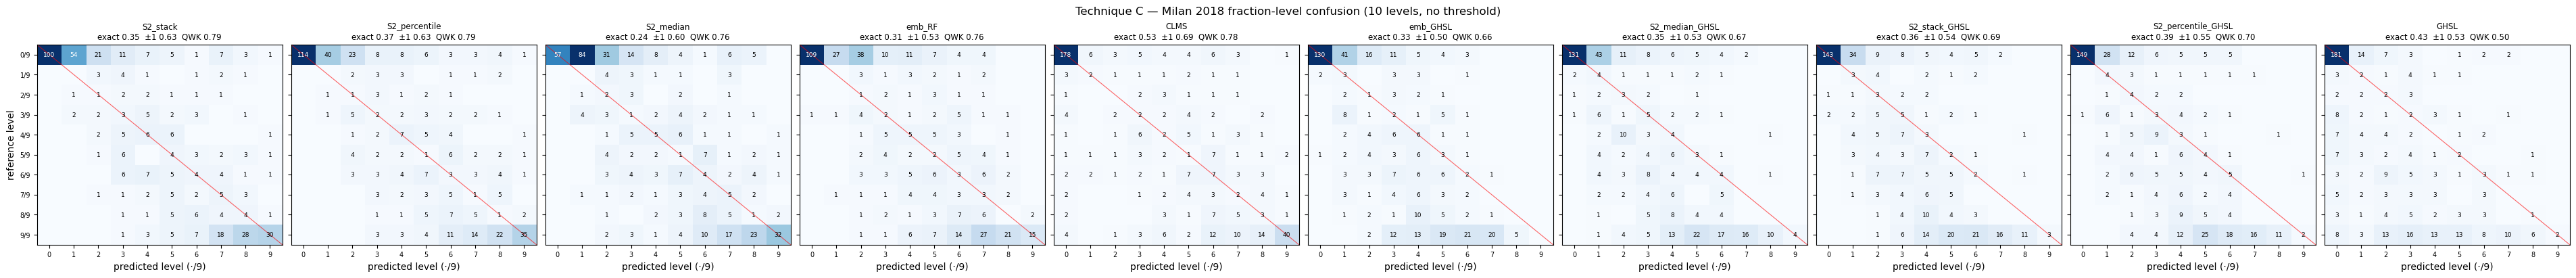

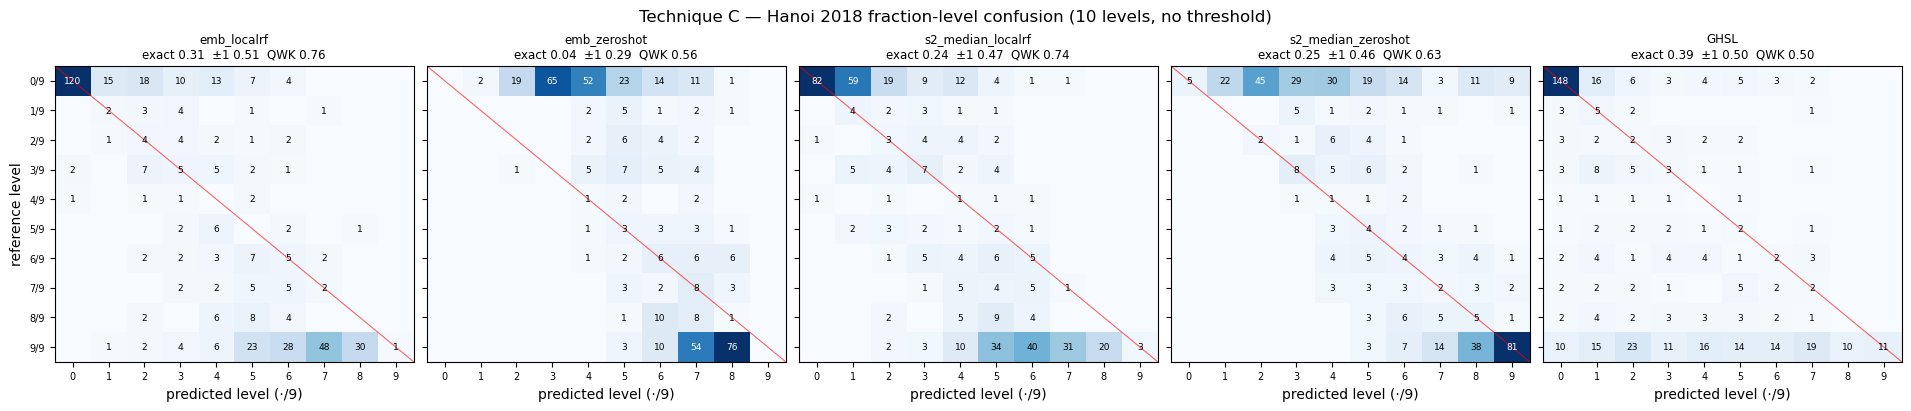

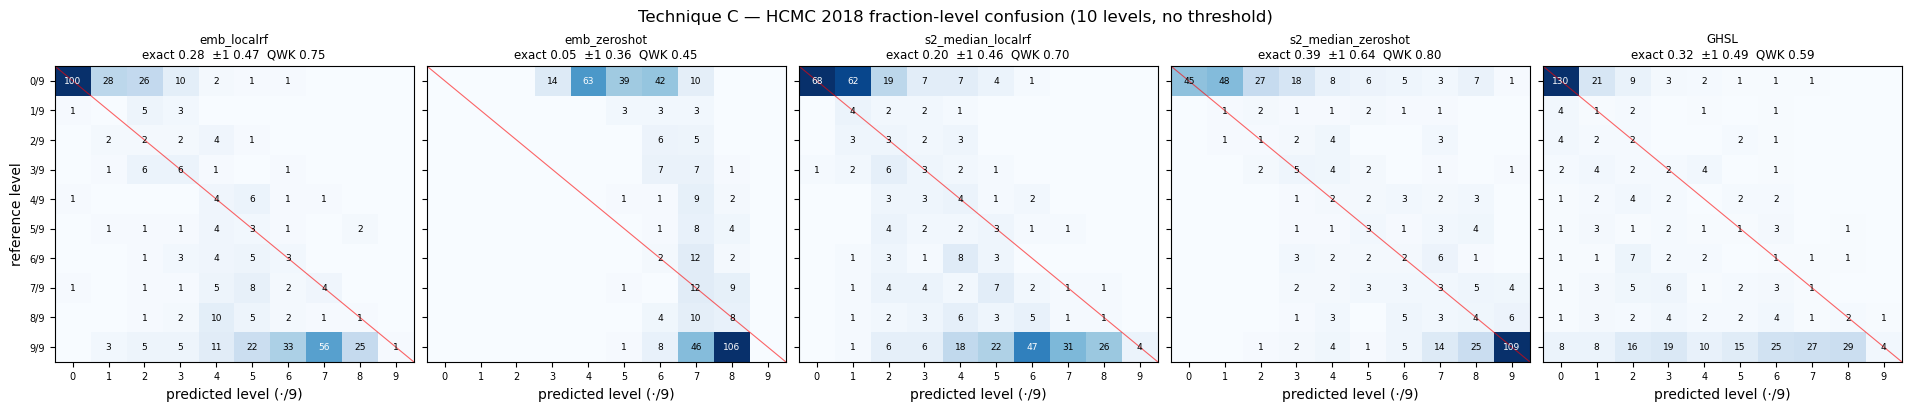

In [9]:
def level_confusion_grid(ds, savepath):
    rs = list(DATASETS[ds]["rasters"])
    fig, axes = plt.subplots(1, len(rs), figsize=(3.8*len(rs), 4.0), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for i, (ax, r) in enumerate(zip(axes, rs)):
        C, _ = level_mats[(ds, r)]; st = TC.loc[(ds, r)]
        Cv = C.values
        ax.imshow(Cv, cmap="Blues", aspect="auto")
        for a in range(10):
            for b in range(10):
                if Cv[a, b]:
                    ax.text(b, a, int(Cv[a, b]), ha="center", va="center", fontsize=6.5,
                            color="white" if Cv[a, b] > Cv.max()/2 else "black")
        ax.plot([-.5, 9.5], [-.5, 9.5], "r-", lw=.8, alpha=.6)
        ax.set_xticks(range(10), [f"{j}" for j in range(10)], fontsize=7)
        ax.set_yticks(range(10), [f"{j}/9" for j in range(10)] if i == 0 else [""]*10, fontsize=7)
        ax.set_xlabel("predicted level (\u00b7/9)")
        if i == 0:
            ax.set_ylabel("reference level")
        ax.set_title(f"{r}\nexact {st.exact_match_OA:.2f}  \u00b11 {st.within_1_level_OA:.2f}  "
                     f"QWK {st.quad_weighted_kappa:.2f}", fontsize=8.5)
    fig.suptitle(f"Technique C \u2014 {ds.replace('_',' ')} fraction-level confusion "
                 "(10 levels, no threshold)", fontsize=12)
    fig.savefig(savepath, dpi=140, bbox_inches="tight"); plt.show()

for ds in DS_ORDER:
    level_confusion_grid(ds, CITY_DIR[ds] / "comparison" / "technique_C_level_confusion_grid.png")

## 6 · Which raster is best, per city

Rank each city’s rasters on the three techniques’ headline agreement statistics —
`R2` (A), `kappa` (B) and `quad_weighted_kappa` (C) — with rank 1 = best, then
average the three ranks. This uses the three techniques, nothing else.

In [10]:
rank_tables = {}
for ds in DS_ORDER:
    sc = pd.DataFrame({
        "R2_continuous": TA.loc[ds, "R2"],
        "kappa_50pct":   TB.loc[ds, "kappa"],
        "QWK_levelconf": TC.loc[ds, "quad_weighted_kappa"],
    })
    ranks = sc.rank(ascending=False, method="min")
    ranks.columns = [c + "_rank" for c in ranks.columns]
    rk = pd.concat([sc, ranks], axis=1)
    rk["MEAN_RANK"] = ranks.mean(axis=1)
    rk = rk.sort_values("MEAN_RANK")
    rank_tables[ds] = rk
    rk.to_csv(CITY_DIR[ds] / "comparison" / "raster_ranking.csv")
    print(f"{ds} \u2014 raster ranking (R2_continuous + kappa_50pct + QWK, all higher-is-better)")
    display(rk.round(3))
pd.concat(rank_tables, names=["dataset", "raster"]).to_csv(CROSS / "raster_ranking_all_cities.csv")

Milan_2018 — raster ranking (R2_continuous + kappa_50pct + QWK, all higher-is-better)


,R2_continuous,kappa_50pct,QWK_levelconf,R2_continuous_rank,kappa_50pct_rank,QWK_levelconf_rank,MEAN_RANK
raster,,,,,,,
S2_stack,0.654,0.692,0.793,1.000,1.000,1.000,1.000
S2_percentile,0.649,0.666,0.788,2.000,3.000,2.000,2.333
S2_median,0.615,0.670,0.760,4.000,2.000,4.000,3.333
CLMS,0.606,0.635,0.779,5.000,4.000,3.000,4.000
emb_RF,0.626,0.627,0.760,3.000,5.000,5.000,4.333
S2_percentile_GHSL,0.543,0.526,0.696,6.000,6.000,6.000,6.000
S2_stack_GHSL,0.538,0.483,0.687,7.000,8.000,7.000,7.333
S2_median_GHSL,0.509,0.484,0.668,9.000,7.000,8.000,8.000
emb_GHSL,0.521,0.471,0.665,8.000,9.000,9.000,8.667


Hanoi_2018 — raster ranking (R2_continuous + kappa_50pct + QWK, all higher-is-better)


,R2_continuous,kappa_50pct,QWK_levelconf,R2_continuous_rank,kappa_50pct_rank,QWK_levelconf_rank,MEAN_RANK
raster,,,,,,,
emb_localrf,0.649,0.726,0.760,1.000,1.000,1.000,1.000
s2_median_localrf,0.628,0.725,0.741,2.000,2.000,2.000,2.000
s2_median_zeroshot,0.429,0.615,0.631,3.000,3.000,3.000,3.000
emb_zeroshot,0.410,0.599,0.561,4.000,4.000,4.000,4.000
GHSL,0.187,0.381,0.501,5.000,5.000,5.000,5.000


HCMC_2018 — raster ranking (R2_continuous + kappa_50pct + QWK, all higher-is-better)


,R2_continuous,kappa_50pct,QWK_levelconf,R2_continuous_rank,kappa_50pct_rank,QWK_levelconf_rank,MEAN_RANK
raster,,,,,,,
s2_median_zeroshot,0.665,0.710,0.803,1.000,1.000,1.000,1.000
emb_localrf,0.630,0.682,0.750,2.000,2.000,2.000,2.000
s2_median_localrf,0.563,0.630,0.703,3.000,3.000,3.000,3.000
GHSL,0.305,0.466,0.590,4.000,4.000,4.000,4.000
emb_zeroshot,0.262,0.366,0.448,5.000,5.000,5.000,5.000


## 7 · Conclusions

In [11]:
print("CONCLUSIONS")
print("-" * 60)
for ds in DS_ORDER:
    rk = rank_tables[ds]
    best = rk.index[0]
    print(f"{ds:11s} best: {best:20s}  R2={rk.loc[best,'R2_continuous']:.3f}  "
          f"kappa@50%={rk.loc[best,'kappa_50pct']:.3f}  QWK={rk.loc[best,'QWK_levelconf']:.3f}")
    print("             order: " + " > ".join(
        f"{r}({rk.loc[r,'MEAN_RANK']:.1f})" for r in rk.index))

print("\n--- files under", RESULTS, "---")
for f in sorted(RESULTS.rglob("*")):
    if f.is_file():
        print("  ", f.relative_to(RESULTS).as_posix())

CONCLUSIONS
------------------------------------------------------------
Milan_2018  best: S2_stack              R2=0.654  kappa@50%=0.692  QWK=0.793
             order: S2_stack(1.0) > S2_percentile(2.3) > S2_median(3.3) > CLMS(4.0) > emb_RF(4.3) > S2_percentile_GHSL(6.0) > S2_stack_GHSL(7.3) > S2_median_GHSL(8.0) > emb_GHSL(8.7) > GHSL(10.0)
Hanoi_2018  best: emb_localrf           R2=0.649  kappa@50%=0.726  QWK=0.760
             order: emb_localrf(1.0) > s2_median_localrf(2.0) > s2_median_zeroshot(3.0) > emb_zeroshot(4.0) > GHSL(5.0)
HCMC_2018   best: s2_median_zeroshot    R2=0.665  kappa@50%=0.710  QWK=0.803
             order: s2_median_zeroshot(1.0) > emb_localrf(2.0) > s2_median_localrf(3.0) > GHSL(4.0) > emb_zeroshot(5.0)

--- files under C:\Users\user\OneDrive - Politecnico di Milano\File di Daniele Oxoli - PhD_Keerthana\test_embeddings\Groundtruth_validation\output\confusion_matrix_validation ---
   cross_city/dataset_summary.csv
   cross_city/raster_ranking_all_cities.csv
  

## Notes / caveats

* Ground truth is the same 450-plot, 9-sub-cell photo-interpretation used throughout this
  project; only the point-sample extraction is used here (no 3×3-window sensitivity check,
  no ROC — out of scope for this notebook by request). Technique A is the continuous
  RMSE / MAE / bias / R2 agreement; techniques B and C are the two confusion-matrix ones.
* `S2_stack`, `S2_percentile`, `S2_median` and `CLMS` for Milan, and `emb_localrf` for Hanoi/HCMC,
  are the same underlying rasters already validated in `imd_groundtruth_validation.ipynb` under
  the names `RF_stack`/`RF_percentile`/`RF_median`/`CLMS`/`AE` — confirmed identical by file
  hash. `emb_RF` (Milan) is likewise identical to that notebook’s `AE` raster. `GHSL` is the
  same file as that notebook’s `IMD2018`. The remaining six — `emb_zeroshot` and
  `s2_median_localrf` / `s2_median_zeroshot` for Hanoi and HCMC — are genuinely new to this
  validation, as are the five GHSL Milan entries (`emb_GHSL`, `S2_median_GHSL`,
  `S2_stack_GHSL`, `S2_percentile_GHSL`, `GHSL`).
* All rasters are 10 m; Milan is EPSG:32632, Hanoi/HCMC EPSG:32648. Every one of the 450 plots
  in every dataset falls inside every raster with no missing values.